In [ ]:
# =========================================
# 🚀 Setup for Google Colab
# =========================================

# Install SpectroChemPy with CP (TensorLy)
!pip install -q "spectrochempy[cp] @ git+https://github.com/atravert/spectrochempy.git@feature/CP" >& install.log

# Clone the repo
!git clone https://github.com/atravert/psd_raman_hoyer.git

# Move into repo
%cd psd_raman_hoyer

# Check structure
from pathlib import Path
DATA = Path("data")

assert DATA.exists(), "❌ data/ folder missing after clone"

print("✅ Setup complete")

## Analysis of Raman MES data from Hoyer et al. (2024)

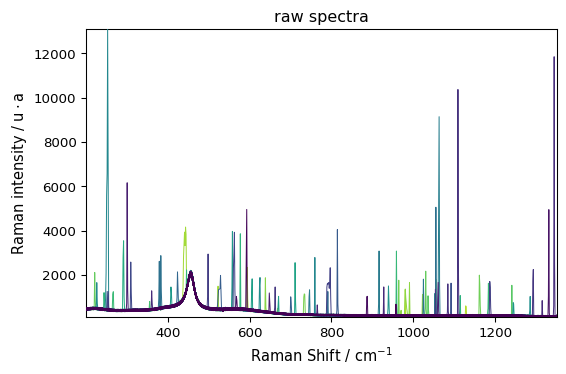

In [ ]:
# Imports

import numpy as np
import spectrochempy as scp
import utilities as u
from importlib import reload
import matplotlib.pyplot as plt 

from pathlib import Path

ROOT = Path.cwd()
DATA = ROOT / "data"

assert DATA.exists(), "data folder not found"

# read raw raman data
D_1 = u.read_raman_raw('data/Fig_2-a-c_raw-data.txt')
D_1.y -= D_1.y[0] 
D_1.plot(title='raw spectra')
scp.show()


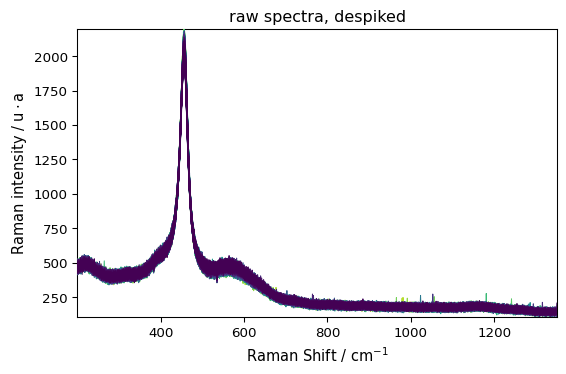

In [44]:
# remove spikes

D_2 = D_1.copy()
diff = D_1[1:] - D_1[:-1]
spectrum, spike = np.where(diff.data > 100)
for spec_idx, spike_idx in zip(spectrum, spike):
    D_2.data[spec_idx+1, spike_idx] = 0.5 * (D_1.data[spec_idx+2, spike_idx] + D_1.data[spec_idx, spike_idx])

D_2.plot(title='raw spectra, despiked')
scp.show()


PC	Eigenvalue		%variance		%cumulative
  	 of cov(X)		   per PC		   variance
#1	 1.491e+02		   11.574		     11.574
#2	 4.078e+01		    0.866		     12.439
#3	 3.829e+01		    0.763		     13.203
#4	 3.533e+01		    0.650		     13.852
#5	 3.470e+01		    0.627		     14.479



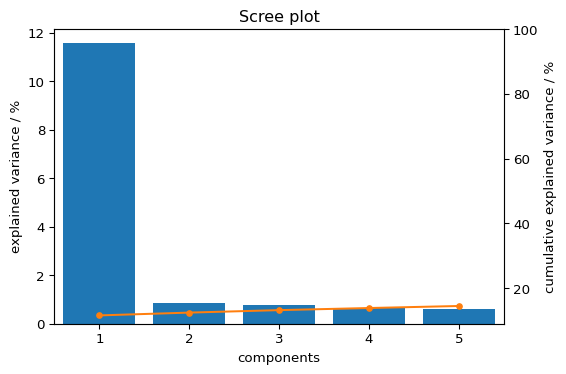

In [45]:
#  statistical analysis in the time domain with PCA

pca = scp.PCA(n_components=5)
pca.fit(D_2)

print(pca)
_ = pca.plot_scree()

## interpretation of the screeplot: 
the 1st component describes 11.6% of the variance. The next ones are of the same order of magnitude and are 
dominated by noise.  This can be confirmed below from the scores of the PCA (note that the signs in PCA are arbitrary: I will multiply scores and
loadings by -1 for consistency with the ppt presentation): 

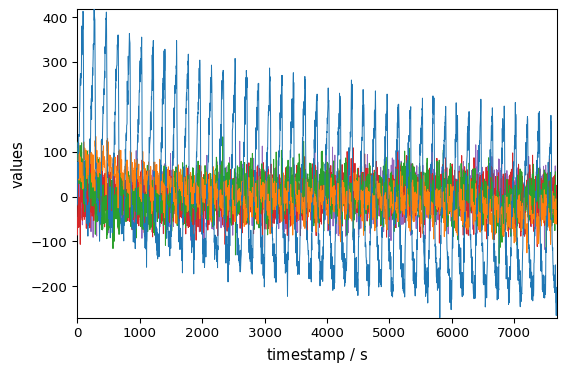

In [46]:

_ =  (- pca.scores).T.plot()

## interpretation of the scores:

The scores of the 1st component (blue) show large oscillations, reflecting the periodic perturbations and a lobal downward trend that suggests a slower evolution over time. The second one (orange) has a much lower amplitude and is noisy, note that it also show a downward trend, but much weaker. The remaining scores are mostly noise.  

In the following I consider only the first component. As it it clearly dominent, inclusion of the other ones should not changhe much the conclusions.

Below we plot the loading (-> a first order approximation of the 'reaction spectrum' ) and the score (the same as above)

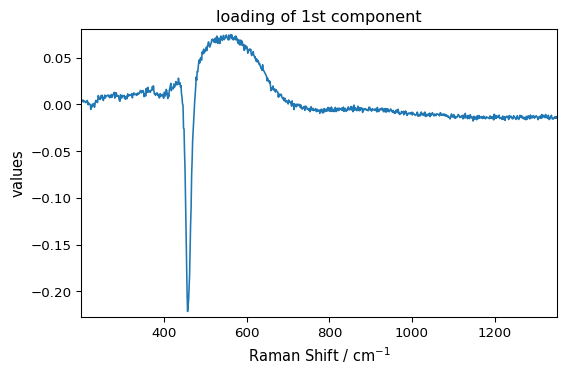

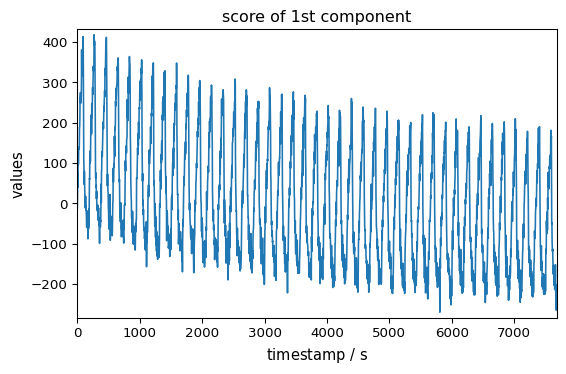

In [47]:

rt = - pca.loadings[0]
x = - pca.scores[:,0]

_ = rt.plot(title='loading of 1st component')
_ = x.plot(title='score of 1st component')

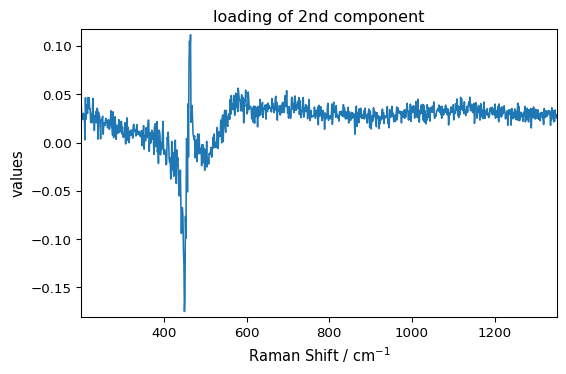

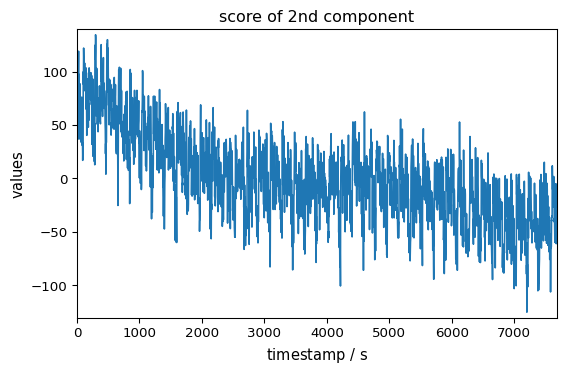

In [48]:
# Note: the second component still has a structured loading, which could reflect some shifts of the thin peak at 425 cm-1 within each cycle; the fact that score is
# seems also evolving in parallel with that of the 1st component seems to support this  
#    

rt_2 = - pca.loadings[1]
x_2 = - pca.scores[:,1]

_ = rt_2.plot(title='loading of 2nd component')
_ = x_2.plot(title='score of 2nd component')

Coming back to the first component: the scores are changing in terms of both mean and amplitude.  We can assess the change of amplitude within each cycle by computing their standard deviations in each cycle: 
 

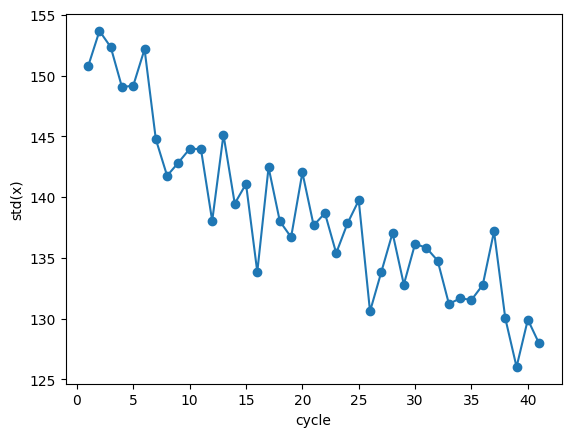

In [49]:
# compute the standard deviation of the scores within each cycle 
N = 41 # cycles
n = 60 # spectra per period

data = np.array(x.data).reshape(N, n)   # (cycles, points_per_cycle)

data_centered = data - data.mean(axis=1, keepdims=True)
std_per_cycle = data.std(axis=1)


plt.figure()
plt.plot(np.arange(N) + 1, std_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('std(x)')
plt.show()

There is a clear trend showing a progressive decrease in the amplitude of the modulated response in each cycle, indicating that the system becomes less responsive to the excitation. The loss between first and last cycles is ~ 17%. 

Note that beyond this decrease in amplitude, there is also a substantial shift of the mean level, which may reflect a continuous baseline drift over time. 

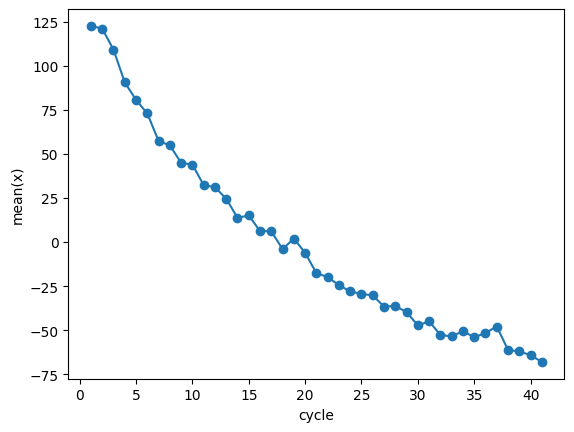

In [50]:
mean_level_per_cycle = data.mean(axis=1)

plt.figure()
plt.plot(np.arange(N) + 1, mean_level_per_cycle, 'o-')
plt.xlabel('cycle')
plt.ylabel('mean(x)')
plt.show()

## CP decomposition

Here a demonstration of CP (or PARAFAC) decompositon. We fist need to create a 3D dataset (N cycles x n spectra per cycle x wavenembers)

In [51]:
N = 41 # cycles
n = 60 # spectra per period



D_3way = scp.NDDataset(D_2.data.reshape(N, n, D_2.shape[1]))
times = D_2.y.data.reshape(N, n) 
ave_rel_times = np.mean(times - np.expand_dims(times[:,0], axis=1), axis=0)
D_3way.units = D_2.units
D_3way.title = D_2.title
D_3way.set_coordset(z=scp.Coord(np.arange(1, N+1, 1), title='period', units=None),
                        y=scp.Coord(ave_rel_times, title='time', units='s'),
                        x= D_2.x)

# Next subtract from each cycle the mean first spectrum. 
D_3way_diff = D_3way - D_3way[:,0,:].data.mean(axis=0)   

In [52]:
cp_list = []

for n_components in [1,2]:
    cp = scp.CP(n_components=n_components)
    cp.fit(D_3way_diff)
    print(f'{n_components} components: CC = {cp.core_consistency} ')
    cp_list.append(cp)

1 components: CC = 100.0 
2 components: CC = 11.612567889059832 


The core consistency diganostic suggests a single component CP. The loadings are plotted below. NB: the A, B and C matrices can be arbitrarily multiplied by three numbers a, b, c with abc=1 ; below we use a = -1, b= 1, c=-1 so as to have consistent profiles. 

<Axes: xlabel='Raman Shift $\\mathrm{/\\ \\mathrm{cm}^{-1}}$', ylabel='values $\\mathrm{}$'>

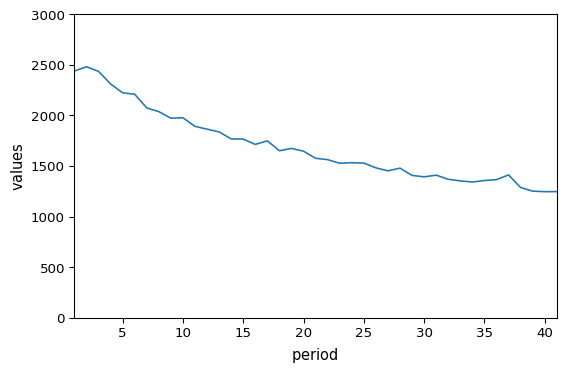

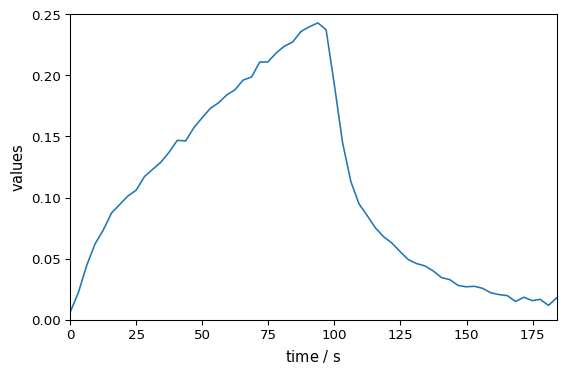

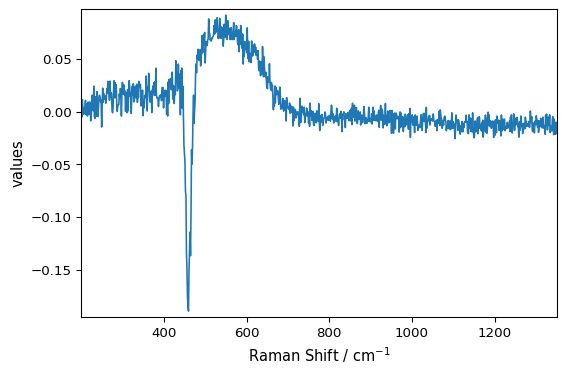

In [53]:
cp  = cp_list[0]
loadings = cp.loadings

A = - cp.A
B = cp.B
C = - cp.C

A.plot(ylim=(0, 3000))
B.plot(ylim=(0, 0.25))
C.plot()
